In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# df1 = pd.read_csv("bank.csv", sep=';')
df = pd.read_csv("../data/bank-full.csv", sep=";")


In [4]:
df.y = (df.y == 'yes').astype(int)

In [5]:
categorical = ['job', 'marital', 'education', 'default',  'housing',
               'loan', 'contact', 'month', 'poutcome']

numerical = ['age', 'balance', 'day', 'duration', 
             'campaign', 'pdays','previous']

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
df_full_train, df_test = train_test_split(df, test_size=.2, random_state=24)
df_train, df_val = train_test_split(df_full_train, test_size=.25, random_state=24)

In [8]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)



In [9]:
y_train = df_train.y.values
y_val = df_val.y.values
y_test = df_test.y.values

In [10]:
del df_train['y']
del df_val['y']
del df_test['y']

In [11]:
df_full_train.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [12]:
from sklearn.feature_extraction import DictVectorizer

In [37]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [38]:
print(df_val.shape)
print(X_val.shape)
   # Should match y_val.shape[0]
print(y_val.shape)

(7233, 17)
(7233, 51)
(7233,)


In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
# Base model
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
y_pred = model.predict_proba(X_val)[:, 1]

In [41]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

In [42]:
# print(y_pred.shape)
# print(y_val.shape)

roc_auc_score(y_val, y_pred)

0.9077752350086159

In [43]:
def train(df, y, C, s, m):
    cat = df[categorical + numerical].to_dict(orient='records')
    
    dv = DictVectorizer(sparse=False)
    dv.fit(cat)
    
    X = dv.transform(cat)

    model = LogisticRegression(solver=s, C=C, max_iter=m)
    model.fit(X, y)
    return dv, model

In [44]:
def predict(df, dv, model):
    cat = df[categorical + numerical].to_dict(orient='records')
    X = dv.transform(cat)
    y_pred = model.predict_proba(X)[:, 1]
    return y_pred

In [45]:
solvers = ['lbfgs', 'liblinear', 'newton-cg']
iters = [100, 200]
cs = [1, 5, 10]

In [46]:
nfolds = 5

kfold = KFold(n_splits=nfolds, shuffle=True, random_state=24)

scores = []
for C in cs:
    for s in solvers:
        for m in iters:   
            for train_idx, val_idx in kfold.split(df_full_train):
                df_train = df_full_train.iloc[train_idx].reset_index(drop=True)
                df_val = df_full_train.iloc[val_idx].reset_index(drop=True)
                y_train = df_train.y.values
                y_val = df_val.y.values
                dv, model = train(df_train, y_train, C=C, s=s, m=m)
                y_pred = predict(df_val, dv, model)
                auc = roc_auc_score(y_val, y_pred)
                scores.append((C,s,m, auc))

                print(f'C={C}, solver={s}, max_iter = {m}, auc = {auc}')

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=1, solver=lbfgs, max_iter = 100, auc = 0.850340710301714


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=1, solver=lbfgs, max_iter = 100, auc = 0.8539753522068857


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=1, solver=lbfgs, max_iter = 100, auc = 0.8547794866225956


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=1, solver=lbfgs, max_iter = 100, auc = 0.8492268389433175


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=1, solver=lbfgs, max_iter = 100, auc = 0.8472968352580086


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=1, solver=lbfgs, max_iter = 200, auc = 0.8813801801722273


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=1, solver=lbfgs, max_iter = 200, auc = 0.8799120560439267


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=1, solver=lbfgs, max_iter = 200, auc = 0.8812452772989091


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=1, solver=lbfgs, max_iter = 200, auc = 0.8723598577340721


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=1, solver=lbfgs, max_iter = 200, auc = 0.8702060002169254
C=1, solver=liblinear, max_iter = 100, auc = 0.8992648043279
C=1, solver=liblinear, max_iter = 100, auc = 0.9075051876008906
C=1, solver=liblinear, max_iter = 100, auc = 0.9081037780100482
C=1, solver=liblinear, max_iter = 100, auc = 0.9051662267586236
C=1, solver=liblinear, max_iter = 100, auc = 0.9079032713371733
C=1, solver=liblinear, max_iter = 200, auc = 0.8992648043279
C=1, solver=liblinear, max_iter = 200, auc = 0.9075051876008906
C=1, solver=liblinear, max_iter = 200, auc = 0.9081037780100482
C=1, solver=liblinear, max_iter = 200, auc = 0.9051662267586236
C=1, solver=liblinear, max_iter = 200, auc = 0.9079032713371733
C=1, solver=newton-cg, max_iter = 100, auc = 0.8993457244038765
C=1, solver=newton-cg, max_iter = 100, auc = 0.9074098710085944
C=1, solver=newton-cg, max_iter = 100, auc = 0.9075973837932734
C=1, solver=newton-cg, max_iter = 100, auc = 0.9053113205347297
C=1, solver=newton-cg, max_iter = 100, auc = 0.907

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=5, solver=lbfgs, max_iter = 100, auc = 0.8502502269440313


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=5, solver=lbfgs, max_iter = 100, auc = 0.8542726359255483


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=5, solver=lbfgs, max_iter = 100, auc = 0.8554825186532552


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=5, solver=lbfgs, max_iter = 100, auc = 0.8540208557497666


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=5, solver=lbfgs, max_iter = 100, auc = 0.8461947890471296


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=5, solver=lbfgs, max_iter = 200, auc = 0.871491930797151


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=5, solver=lbfgs, max_iter = 200, auc = 0.8720973960919083


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=5, solver=lbfgs, max_iter = 200, auc = 0.8813540596753345


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=5, solver=lbfgs, max_iter = 200, auc = 0.8730634885207504


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=5, solver=lbfgs, max_iter = 200, auc = 0.8702426333319686
C=5, solver=liblinear, max_iter = 100, auc = 0.8992824596172039
C=5, solver=liblinear, max_iter = 100, auc = 0.9077517472850565
C=5, solver=liblinear, max_iter = 100, auc = 0.9077397246844369
C=5, solver=liblinear, max_iter = 100, auc = 0.9047888718995923
C=5, solver=liblinear, max_iter = 100, auc = 0.907810251956819
C=5, solver=liblinear, max_iter = 200, auc = 0.8992824596172039
C=5, solver=liblinear, max_iter = 200, auc = 0.9077517472850565
C=5, solver=liblinear, max_iter = 200, auc = 0.9077397246844369
C=5, solver=liblinear, max_iter = 200, auc = 0.9047888718995923
C=5, solver=liblinear, max_iter = 200, auc = 0.907810251956819
C=5, solver=newton-cg, max_iter = 100, auc = 0.8992609422333646
C=5, solver=newton-cg, max_iter = 100, auc = 0.9073712241251684
C=5, solver=newton-cg, max_iter = 100, auc = 0.9075994576340719
C=5, solver=newton-cg, max_iter = 100, auc = 0.9053263110906795
C=5, solver=newton-cg, max_iter = 100, auc = 0

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, solver=lbfgs, max_iter = 100, auc = 0.8502182267321676


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, solver=lbfgs, max_iter = 100, auc = 0.8565498292105036


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, solver=lbfgs, max_iter = 100, auc = 0.8548198322526738


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, solver=lbfgs, max_iter = 100, auc = 0.8518031788121632


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, solver=lbfgs, max_iter = 100, auc = 0.8703238008221621


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, solver=lbfgs, max_iter = 200, auc = 0.8713940910689248


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, solver=lbfgs, max_iter = 200, auc = 0.8724281242289205


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, solver=lbfgs, max_iter = 200, auc = 0.8813122057974031


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, solver=lbfgs, max_iter = 200, auc = 0.8725680599000408


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=10, solver=lbfgs, max_iter = 200, auc = 0.8702611294635834
C=10, solver=liblinear, max_iter = 100, auc = 0.8992179074656862
C=10, solver=liblinear, max_iter = 100, auc = 0.9077374405060958
C=10, solver=liblinear, max_iter = 100, auc = 0.9077689469865962
C=10, solver=liblinear, max_iter = 100, auc = 0.9049981844771128
C=10, solver=liblinear, max_iter = 100, auc = 0.9071930557979805
C=10, solver=liblinear, max_iter = 200, auc = 0.8992179074656862
C=10, solver=liblinear, max_iter = 200, auc = 0.9077374405060958
C=10, solver=liblinear, max_iter = 200, auc = 0.9077689469865962
C=10, solver=liblinear, max_iter = 200, auc = 0.9049981844771128
C=10, solver=liblinear, max_iter = 200, auc = 0.9071930557979805
C=10, solver=newton-cg, max_iter = 100, auc = 0.8992600226870467
C=10, solver=newton-cg, max_iter = 100, auc = 0.9073667648693884
C=10, solver=newton-cg, max_iter = 100, auc = 0.9074825684254345
C=10, solver=newton-cg, max_iter = 100, auc = 0.9053214993072884
C=10, solver=newton-cg, max_i

In [47]:
columns = ["C", "solver",'max_depth', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores.sort_values(by='auc',ascending=False)

,C,solver,max_depth,auc
17,1,liblinear,200,0.908104
12,1,liblinear,100,0.908104
19,1,liblinear,200,0.907903
14,1,liblinear,100,0.907903
24,1,newton-cg,100,0.907834
...,...,...,...,...
30,5,lbfgs,100,0.850250
60,10,lbfgs,100,0.850218
3,1,lbfgs,100,0.849227
4,1,lbfgs,100,0.847297


In [48]:
#final log model
model = LogisticRegression(C=1, solver='liblinear', max_iter=100)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [49]:
y_pred = model.predict_proba(X_val)[:, 1]

In [51]:
roc_auc_score(y_val, y_pred)

0.9079032713371733

XGBoost

In [55]:
import xgboost as xgb

In [56]:
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=dv.feature_names_)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=dv.feature_names_)

In [57]:
xgb_params = { 
'eta': 0.3, 
'max_depth': 6, 
'min_child_weight': 1, 
'objective': 'binary:logistic',
'eval_metric' : 'auc',
'nthread': 8, 
'seed': 1, 
'verbosity' : 1
} 

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [58]:
y_pred = model.predict(dval)

In [59]:
y_pred[:10]

array([0.01592336, 0.01048785, 0.0402237 , 0.10238014, 0.01384054,
       0.06318122, 0.70297277, 0.04680746, 0.00775846, 0.01202045],
      dtype=float32)

In [60]:
roc_auc_score(y_val, y_pred)

0.9232860371086273

In [61]:
watchlist = [(dtrain, 'train'), (dval, 'val')] 


In [62]:
%%capture output

xgb_params = { 
'eta': 0.3, 
'max_depth': 6, 
'min_child_weight': 1, 
'objective': 'binary:logistic',
'eval_metric' : 'auc',
'nthread': 8, 
'seed': 1, 
'verbosity' : 1
} 

model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval = 5,
                  evals=watchlist)

In [63]:
s = output.stdout

In [64]:
print(s[:200])

[0]	train-auc:0.86089	val-auc:0.86171
[5]	train-auc:0.93107	val-auc:0.91906
[10]	train-auc:0.94117	val-auc:0.92480
[15]	train-auc:0.94895	val-auc:0.92748
[20]	train-auc:0.95459	val-auc:0.93000
[25]	tr


In [65]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))
    
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [66]:
df_score = parse_xgb_output(output)

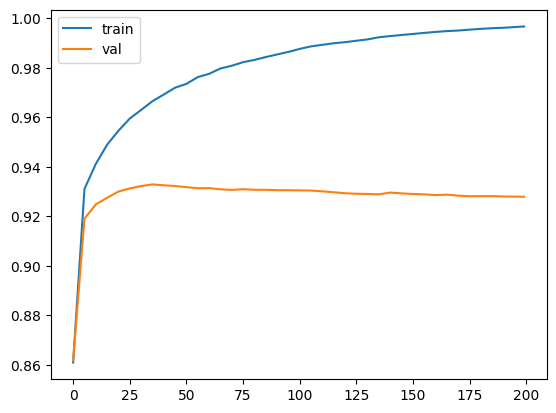

In [67]:
plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

In [70]:
# Another parameter for XGboost

xgb_params = { 
'eta': 0.1, 
'max_depth': 6, 
'min_child_weight': 1, 
'objective': 'binary:logistic',
'eval_metric' : 'auc',
'nthread': 8, 
'seed': 1, 
'verbosity' : 1
} 

model = xgb.train(xgb_params, dtrain, num_boost_round=15)

In [71]:
y_pred = model.predict(dval)

In [72]:
y_pred[:10]

array([0.03993127, 0.03395326, 0.06407091, 0.12254988, 0.0325421 ,
       0.07625646, 0.59228116, 0.07001418, 0.0312609 , 0.03535197],
      dtype=float32)

In [73]:
roc_auc_score(y_val, y_pred)

0.9199710993454164

In [74]:
xgb_params = { 
'eta': 0.3, 
'max_depth': 6, 
'min_child_weight': 1, 
'objective': 'binary:logistic',
'eval_metric' : 'auc',
'nthread': 8, 
'seed': 1, 
'verbosity' : 1
} 

model = xgb.train(xgb_params, dtrain, num_boost_round=15)

In [75]:
y_pred = model.predict(dval)

In [76]:
y_pred[:10]

array([0.0107707 , 0.00421339, 0.03757695, 0.09116881, 0.00773876,
       0.14374194, 0.85422194, 0.04239385, 0.0051235 , 0.00875375],
      dtype=float32)

In [77]:
roc_auc_score(y_val, y_pred)

0.9277036495920435

In [ ]:
import pickle

In [ ]:
with open('bank-model.bin', 'wb') as f_out:      
    pickle.dump((dv, model), f_out)

#### Load the model

In [ ]:
with open('bank-model.bin', 'rb') as f_in:
    dv, model = pickle.load(f_in)

In [ ]:
# customer = 
df_val.iloc[9].to_dict()

{'age': 40,
 'job': 'housemaid',
 'marital': 'married',
 'education': 'secondary',
 'default': 'no',
 'balance': 0,
 'housing': 'no',
 'loan': 'no',
 'contact': 'cellular',
 'day': 19,
 'month': 'nov',
 'duration': 107,
 'campaign': 3,
 'pdays': -1,
 'previous': 0,
 'poutcome': 'unknown'}

In [ ]:
y_val.dtype

dtype('int32')

In [ ]:
customer = {"age": 34,
 "job": "technician",
 "marital": "married",
 "education": "secondary",
 "default": "no",
 "balance": -346,
 "housing": "yes",
 "loan": "no",
 "contact": "unknown",
 "day": 3,
 "month": "jul",
 "duration": 115,
 "campaign": 4,
 "pdays": -1,
 "previous": 0,
 "poutcome": "unknown"}

In [ ]:
dv.get_feature_names_out()

array(['age', 'balance', 'campaign', 'contact=cellular',
       'contact=telephone', 'contact=unknown', 'day', 'default=no',
       'default=yes', 'duration', 'education=primary',
       'education=secondary', 'education=tertiary', 'education=unknown',
       'housing=no', 'housing=yes', 'job=admin.', 'job=blue-collar',
       'job=entrepreneur', 'job=housemaid', 'job=management',
       'job=retired', 'job=self-employed', 'job=services', 'job=student',
       'job=technician', 'job=unemployed', 'job=unknown', 'loan=no',
       'loan=yes', 'marital=divorced', 'marital=married',
       'marital=single', 'month=apr', 'month=aug', 'month=dec',
       'month=feb', 'month=jan', 'month=jul', 'month=jun', 'month=mar',
       'month=may', 'month=nov', 'month=oct', 'month=sep', 'pdays',
       'poutcome=failure', 'poutcome=other', 'poutcome=success',
       'poutcome=unknown', 'previous'], dtype=object)

In [ ]:
sample = dv.transform([customer])
feature_names = dv.get_feature_names_out().tolist()

X =xgb.DMatrix(sample, feature_names=feature_names)


In [ ]:
y_pred = model.predict(X)

result = (y_pred >= 0.5).astype(int)
print(result[0])

# dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=dv.feature_names_)


[0]
